# Yb:YAG reflection

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
DATA_DIR = ROOT / "data" / "reflection"
FIGURE_PATH = ROOT / "figures" / "YbYAG_reflection.png"

pure_files = {
    "Pure sample A": "YbYag_A_A.txt",
    "Pure sample B": "YbYag_B_A.txt",
}

paired_files = {
    "5%": {"A": "YbYag_5_A_R.txt", "B": "YbYag_5_B_R.txt"},
    "10%": {"A": "YbYag_10_A_R.txt", "B": "YbYag_10_B_R.txt"},
    "15%": {"A": "YbYag_15_A_R.txt", "B": "YbYag_15_B_R.txt"},
}


def load_reflection(path):
    rows = []
    for line in path.read_text(encoding="ascii").splitlines()[2:]:
        fields = line.strip().split(",")
        if len(fields) != 4:
            continue
        wavelength = float(f"{fields[0]}.{fields[1]}")
        reflectance = float(f"{fields[2]}.{fields[3]}")
        rows.append((wavelength, reflectance))
    return np.asarray(rows)


pure_spectra = {
    sample: load_reflection(DATA_DIR / filename)
    for sample, filename in pure_files.items()
}

paired_spectra = {
    concentration: {
        side: load_reflection(DATA_DIR / filename)
        for side, filename in sides.items()
    }
    for concentration, sides in paired_files.items()
}

In [2]:
higher_reflection_side = {}

for concentration, sides in paired_spectra.items():
    means = {side: values[:, 1].mean() for side, values in sides.items()}
    selected = max(means, key=means.get)
    higher_reflection_side[concentration] = selected
    print(
        f"{concentration:>3}: {selected} side "
        f"(A = {means['A']:.2f}%, B = {means['B']:.2f}%)"
    )

 5%: A side (A = 80.51%, B = 77.08%)
10%: B side (A = 74.24%, B = 80.97%)
15%: B side (A = 72.87%, B = 80.13%)


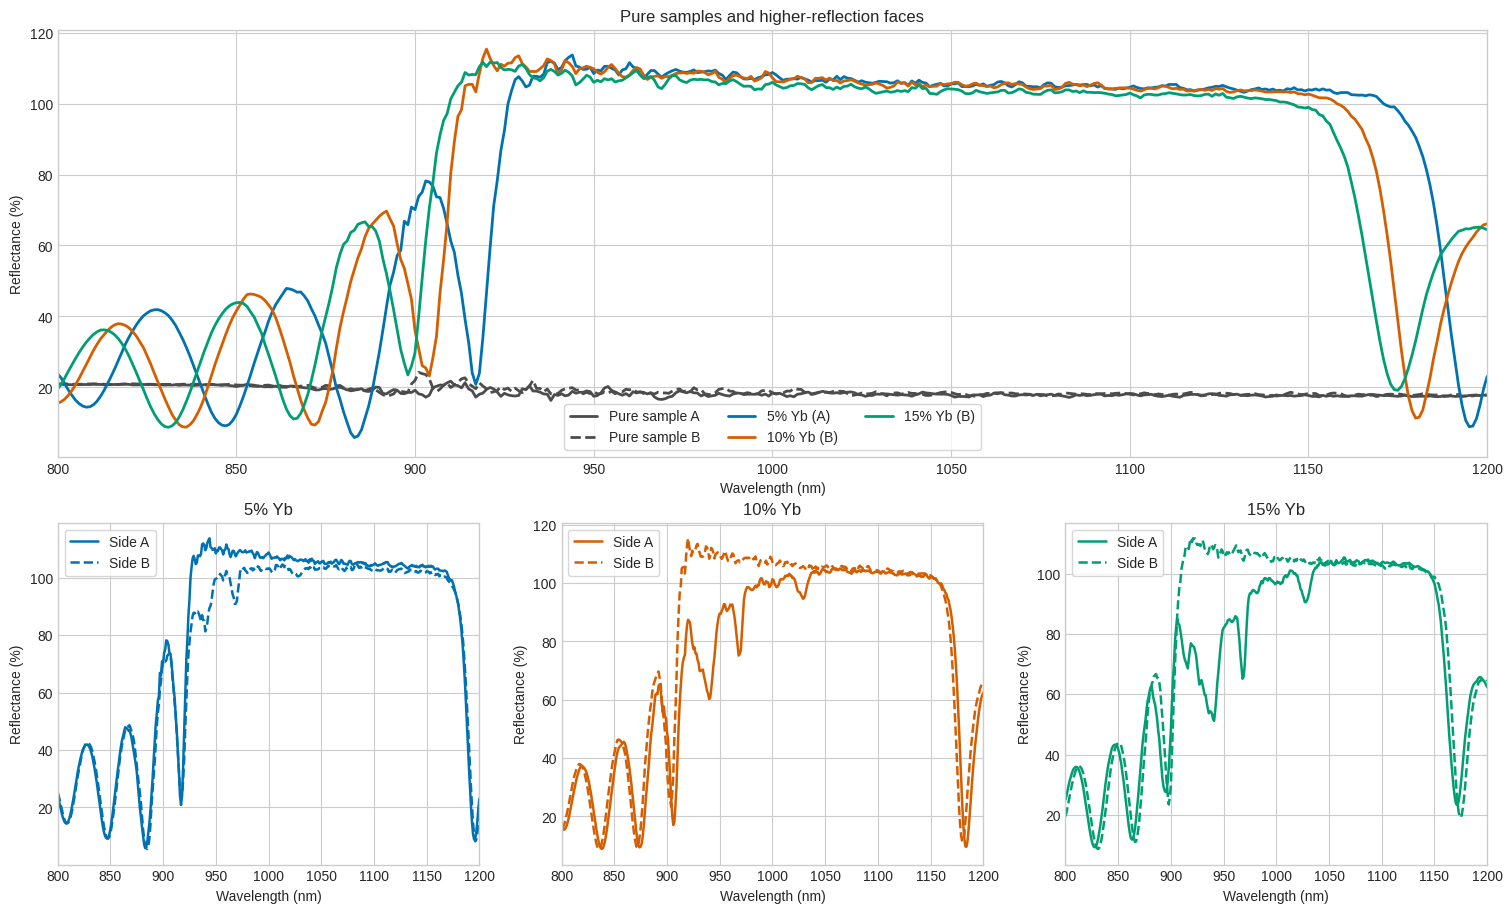

In [3]:
colors = {
    "5%": "#0072b2",
    "10%": "#d55e00",
    "15%": "#009e73",
}

plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(15, 9), constrained_layout=True)
grid = fig.add_gridspec(2, 3, height_ratios=(1.25, 1))
all_ax = fig.add_subplot(grid[0, :])
pair_axes = [
    fig.add_subplot(grid[1, 0]),
    fig.add_subplot(grid[1, 1]),
    fig.add_subplot(grid[1, 2]),
]

for sample, linestyle in (("Pure sample A", "-"), ("Pure sample B", "--")):
    values = pure_spectra[sample]
    all_ax.plot(
        values[:, 0],
        values[:, 1],
        color="#4c4c4c",
        linestyle=linestyle,
        linewidth=2,
        label=sample,
    )

for concentration in paired_files:
    side = higher_reflection_side[concentration]
    values = paired_spectra[concentration][side]
    all_ax.plot(
        values[:, 0],
        values[:, 1],
        color=colors[concentration],
        linewidth=2,
        label=f"{concentration} Yb ({side})",
    )

all_ax.set(
    title="Pure samples and higher-reflection faces",
    xlabel="Wavelength (nm)",
    ylabel="Reflectance (%)",
    xlim=(800, 1200),
)
all_ax.legend(ncol=3, frameon=True)

for ax, concentration in zip(pair_axes, paired_files):
    for side, linestyle in (("A", "-"), ("B", "--")):
        values = paired_spectra[concentration][side]
        ax.plot(
            values[:, 0],
            values[:, 1],
            color=colors[concentration],
            linestyle=linestyle,
            linewidth=1.8,
            label=f"Side {side}",
        )
    ax.set(
        title=f"{concentration} Yb",
        xlabel="Wavelength (nm)",
        ylabel="Reflectance (%)",
        xlim=(800, 1200),
    )
    ax.legend(frameon=True)

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=200, bbox_inches="tight")
plt.show()